# Experiment 5: Decision Trees
## Objective
Build a decision tree classifier using Python and scikit-learn.

**Default dataset:** Student Performance, continuing Experiments 2–4. Predict `pass_fail`: 0 = Fail, 1 = Pass.

**Alternative:** Set `DATASET = "iris"` to use scikit-learn's built-in Iris dataset (three flower species). It needs no CSV or internet download.

**Requirements:** Python, pandas, NumPy, Matplotlib, scikit-learn, Jupyter/Colab, and (for the default mode) the original `student_performance.csv`.

**Learning outcomes:** Prepare inputs, train a classifier, understand Gini impurity, visualize a tree, read decision rules, evaluate predictions, inspect feature importance, and recognize overfitting.

The original CSV is not embedded in the earlier notebooks. No student-data results are prefilled.

## 1. How a decision tree works
A tree asks a sequence of questions, such as “Is Test 2 score ≤ 45?” Each answer leads to another question or a predicted class.

- **Root:** first split.
- **Decision node:** a feature threshold.
- **Branch:** the outcome of a test.
- **Leaf:** a terminal prediction.
- **Depth:** number of edges from the root; the root has depth zero.

A classification tree chooses splits that reduce class impurity. For class proportions \(p_k\):
\[
Gini = 1 - \sum_k p_k^2.
\]
A pure node has Gini = 0. A binary node with equal class proportions has Gini = 0.5. Each candidate split is evaluated using the sample-weighted impurity of its children.

Trees capture nonlinear patterns without feature scaling. They can overfit if allowed to grow too deeply.

## 2. Import libraries
If needed, run `%pip install pandas numpy matplotlib scikit-learn` in a separate cell, then restart the kernel.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

## 3. Load the dataset and select inputs
Student mode uses five pre-final-examination measurements. Final scores and grades are excluded because they may reveal the outcome. IDs and names are not predictors.

Ensure the chosen inputs were available **before** the outcome. For example, use attendance measured by the prediction date, not a later final attendance figure.

Iris mode uses sepal/petal lengths and widths to classify Setosa, Versicolor or Virginica.

In [2]:
DATASET = "student"  # Change to "iris" for the built-in alternative.
DATA_PATH = Path("/kaggle/input/datasets/tahreemrashid/student-performance-dataset/student_performance.csv")

if DATASET == "student":
    if not DATA_PATH.exists():
        raise FileNotFoundError(
            "Place the original student_performance.csv beside this notebook, "
            "edit DATA_PATH, or explicitly set DATASET = 'iris'."
        )
    raw = pd.read_csv(DATA_PATH)
    FEATURES = [
        "test1_score", "test2_score", "attendance_percentage",
        "study_hours_per_week", "assignments_submitted"
    ]
    TARGET = "pass_fail"
    CLASS_LABELS = [0, 1]
    CLASS_NAMES = ["Fail", "Pass"]
elif DATASET == "iris":
    iris = load_iris(as_frame=True)
    raw = iris.frame.copy()
    FEATURES = iris.feature_names
    TARGET = "target"
    CLASS_LABELS = [0, 1, 2]
    CLASS_NAMES = iris.target_names.tolist()
else:
    raise ValueError("DATASET must be 'student' or 'iris'.")

print("Dataset:", DATASET, "| Shape:", raw.shape)
display(raw.head())

Dataset: student | Shape: (1000, 15)


,student_id,name,gender,age,class,teacher_id,subject,test1_score,test2_score,final_exam_score,final_grade_letter,attendance_percentage,study_hours_per_week,assignments_submitted,pass_fail
0,1,Carson Rivera,Female,14,9th,105,Math,23.5,40.5,50.5,F,70.2,3.1,56.7,0
1,2,Ashley Walters,Male,15,10th,107,Computer,77.7,80.6,82.3,B,85.3,6.9,81.0,1
2,3,Linda Robinson,Male,15,10th,103,English,75.0,73.4,64.5,C,83.1,4.3,66.3,1
3,4,Brandon James,Female,17,11th,117,Computer,46.7,53.1,51.2,F,74.1,0.4,44.9,0
4,5,Helen Grant,Female,16,10th,112,Science,38.0,57.3,47.6,F,73.8,1.4,49.9,0


## 4. Check data quality
Remove exact duplicate records, not merely identical predictor combinations. Never fill missing class labels with a guessed class. Predictor imputation will be learned after the split.

In [3]:
required = FEATURES + [TARGET]
missing = sorted(set(required) - set(raw.columns))
if missing:
    raise ValueError(f"Missing required columns: {missing}")
data = raw.drop_duplicates().copy()
print("Exact duplicates removed:", len(raw) - len(data))
target_numeric = pd.to_numeric(data[TARGET], errors="coerce")
invalid = data[TARGET].notna() & (
    target_numeric.isna() | ~target_numeric.isin(CLASS_LABELS)
)
if invalid.any():
    raise ValueError(f"Target labels must be {CLASS_LABELS}. Check the CSV coding.")
data[TARGET] = target_numeric
print("Rows without target removed:", data[TARGET].isna().sum())
data = data.dropna(subset=[TARGET]).copy()
data[TARGET] = data[TARGET].astype(int)
data[FEATURES] = data[FEATURES].apply(pd.to_numeric, errors="coerce")
data[FEATURES] = data[FEATURES].replace([np.inf, -np.inf], np.nan)
if set(data[TARGET].unique()) != set(CLASS_LABELS):
    raise ValueError("Every expected class must be represented.")
display(data[FEATURES].isna().sum().to_frame("Missing predictors"))
display(data[FEATURES].describe().round(2))

Exact duplicates removed: 0
Rows without target removed: 0


,Missing predictors
test1_score,0
test2_score,0
attendance_percentage,0
study_hours_per_week,0
assignments_submitted,0


,test1_score,test2_score,attendance_percentage,study_hours_per_week,assignments_submitted
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,63.94,66.13,82.14,4.26,68.98
std,14.76,14.95,6.90,2.29,14.09
min,17.10,24.40,63.90,0.00,22.80
25%,53.80,56.38,77.20,2.60,59.28
50%,64.00,65.70,82.10,4.10,68.50
75%,73.90,76.93,86.80,5.82,79.10
max,100.00,100.00,100.00,12.00,100.00


## 5. Inspect class balance
Accuracy alone may hide poor performance on the less common class.

,Class,Count,Percent
0,Fail,170,17.0
1,Pass,830,83.0


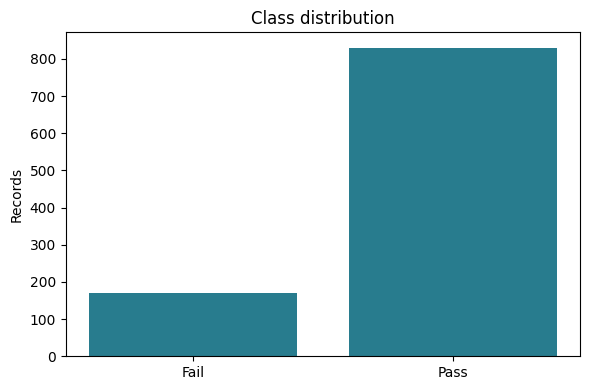

In [4]:
counts = data[TARGET].value_counts().reindex(CLASS_LABELS, fill_value=0)
display(pd.DataFrame({
    "Class": CLASS_NAMES, "Count": counts.to_numpy(),
    "Percent": counts.to_numpy() / len(data) * 100
}).round(2))
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(CLASS_NAMES, counts.to_numpy(), color="#287c8e")
ax.set(title="Class distribution", ylabel="Records")
plt.tight_layout()
plt.show()

## 6. Split into training and testing sets
Use a reproducible 80:20 stratified split. If the same student has multiple records, use a grouped split so that students cannot occur in both partitions. The grouped split is approximately 80:20 by students and is not stratified.

Do not tune model settings on the test set. The depth limit below is a predefined teaching choice, not a claim of optimality.

In [5]:
X = data[FEATURES]
y = data[TARGET]
repeated_students = (
    DATASET == "student" and "student_id" in data.columns
    and data["student_id"].duplicated().any()
)
if repeated_students:
    if data["student_id"].isna().any():
        raise ValueError("Resolve missing student IDs before a grouped split.")
    split = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
    train_idx, test_idx = next(split.split(X, y, groups=data["student_id"]))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    assert set(data.loc[X_train.index, "student_id"]).isdisjoint(
        set(data.loc[X_test.index, "student_id"])
    )
    print("Used student-grouped split.")
else:
    if y.value_counts().min() < 2:
        raise ValueError("Need at least two examples per class for stratification.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
    )
    print("Used stratified split.")

if set(y_train.unique()) != set(CLASS_LABELS) or set(y_test.unique()) != set(CLASS_LABELS):
    raise ValueError("This split lacks a class; collect more data or design a valid split.")
if X_train.isna().all().any():
    raise ValueError("A predictor is entirely missing in the training partition.")
print("Training shape:", X_train.shape, "| Test shape:", X_test.shape)
display(pd.DataFrame({
    "Train": y_train.value_counts(), "Test": y_test.value_counts()
}).rename(index=dict(zip(CLASS_LABELS, CLASS_NAMES))))

Used stratified split.
Training shape: (800, 5) | Test shape: (200, 5)


,Train,Test
pass_fail,,
Pass,664,166
Fail,136,34


## 7. Train the tree
The pipeline learns median replacements from training inputs only. No standardization is required.

- `criterion="gini"`: split using Gini impurity.
- `max_depth=3`: limit the number of levels of decisions.
- `min_samples_leaf=5`: require at least five training records in each leaf.
- `random_state=42`: support reproducibility.

These restrictions are **pre-pruning**: they limit growth. They are not cost-complexity post-pruning.

In [6]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("tree", DecisionTreeClassifier(
        criterion="gini", max_depth=3, min_samples_leaf=5,
        random_state=RANDOM_STATE
    ))
])
model.fit(X_train, y_train)
tree = model.named_steps["tree"]
print("Fitted depth:", tree.get_depth())
print("Number of leaves:", tree.get_n_leaves())
print("Number of nodes:", tree.tree_.node_count)

Fitted depth: 3
Number of leaves: 7
Number of nodes: 13


## 8. Predict labels and probabilities
The model predicts the class with the highest estimated probability; ties follow scikit-learn's class ordering. A tree's class probabilities reflect training-class proportions in the reached leaf. A probability of 1.0 is not a guarantee of correctness.

In [7]:
y_pred = model.predict(X_test)
probabilities = model.predict_proba(X_test)
results = X_test.copy()
class_map = dict(zip(CLASS_LABELS, CLASS_NAMES))
results["Actual"] = y_test.map(class_map)
results["Predicted"] = pd.Series(y_pred, index=X_test.index).map(class_map)
for column, label in enumerate(model.classes_):
    results[f"P({class_map[label]})"] = probabilities[:, column]
display(results.head(15).round(3))

,test1_score,test2_score,attendance_percentage,study_hours_per_week,assignments_submitted,Actual,Predicted,P(Fail),P(Pass)
438,62.3,56.1,64.5,3.1,35.3,Fail,Fail,1.000,0.000
875,43.6,42.5,71.7,0.0,52.4,Fail,Fail,0.889,0.111
154,62.0,73.1,90.6,5.0,66.3,Pass,Pass,0.000,1.000
664,57.4,59.0,80.1,3.9,66.9,Pass,Pass,0.000,1.000
984,45.1,44.4,77.2,2.7,68.6,Fail,Pass,0.279,0.721
476,70.4,86.0,93.8,5.5,88.1,Pass,Pass,0.000,1.000
406,60.3,62.2,78.7,1.5,53.3,Pass,Pass,0.000,1.000
912,52.4,69.5,75.4,2.7,52.2,Pass,Pass,0.000,1.000
12,56.8,61.4,79.4,3.3,58.5,Pass,Pass,0.000,1.000
854,56.0,47.9,83.8,1.9,67.4,Pass,Pass,0.279,0.721


## 9. Evaluate and compare with a majority baseline
Accuracy counts all correct predictions. Precision measures the reliability of predicted classes; recall measures the fraction of each actual class recovered. F1 balances precision and recall.

**Macro averages** weight each class equally and work for both binary Student Performance and multiclass Iris. The report also shows each class separately. Undefined precision/recall is reported as zero.

,Accuracy,Macro precision,Macro recall,Macro F1
Model,,,,
Majority baseline,0.83,0.4150,0.5000,0.4536
Depth-limited tree,0.96,0.9382,0.9174,0.9274


              precision    recall  f1-score   support

        Fail       0.91      0.85      0.88        34
        Pass       0.97      0.98      0.98       166

    accuracy                           0.96       200
   macro avg       0.94      0.92      0.93       200
weighted avg       0.96      0.96      0.96       200



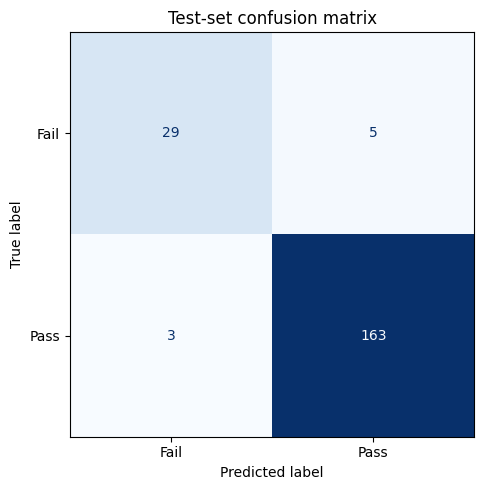

In [8]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

def metrics(name, predictions):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro precision": precision_score(y_test, predictions, average="macro", zero_division=0),
        "Macro recall": recall_score(y_test, predictions, average="macro", zero_division=0),
        "Macro F1": f1_score(y_test, predictions, average="macro", zero_division=0)
    }

scores = pd.DataFrame([
    metrics("Majority baseline", baseline.predict(X_test)),
    metrics("Depth-limited tree", y_pred)
]).set_index("Model")
display(scores.round(4))
print(classification_report(
    y_test, y_pred, labels=CLASS_LABELS,
    target_names=CLASS_NAMES, zero_division=0
))
cm = confusion_matrix(y_test, y_pred, labels=CLASS_LABELS)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Test-set confusion matrix")
plt.tight_layout()
plt.show()

### Read the confusion matrix
Rows represent actual classes; columns represent predicted classes. Diagonal cells are correct.

For Student Performance, with Pass as positive:
- Top-left: actual Fail, predicted Fail (TN).
- Top-right: actual Fail, predicted Pass (FP)—potentially missed support.
- Bottom-left: actual Pass, predicted Fail (FN).
- Bottom-right: actual Pass, predicted Pass (TP).

For Iris, inspect which species are confused rather than assigning a single binary TN/FP/FN/TP interpretation.

## 10. Visualize the complete trained tree
Follow left when a displayed “≤” condition is true; otherwise follow right.

Each node shows the split (unless a leaf), impurity, sample proportion, class proportions, and predicted class. `proportion=True` displays proportions instead of raw class counts. The depth limit keeps the full tree readable.

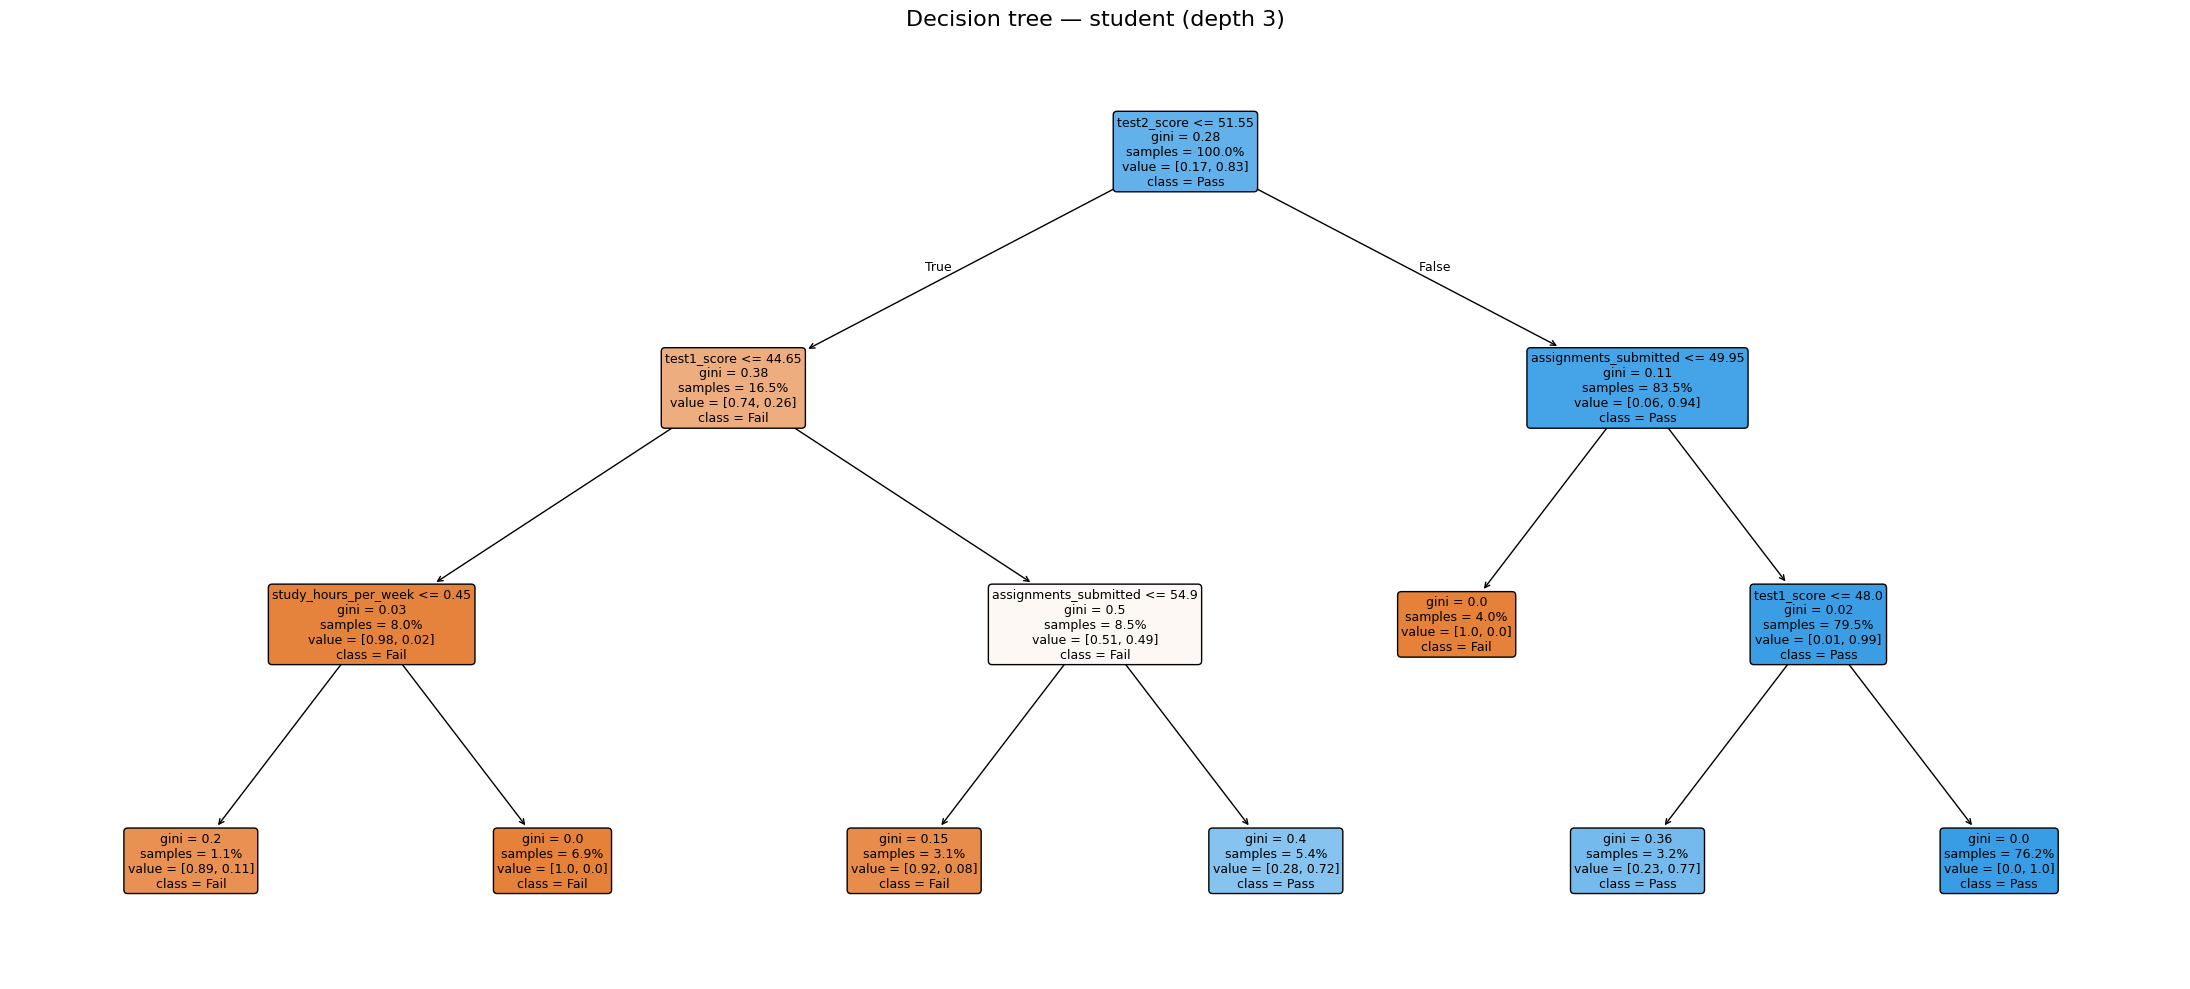

In [9]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    tree, feature_names=FEATURES, class_names=CLASS_NAMES,
    filled=True, rounded=True, proportion=True, precision=2,
    fontsize=9, ax=ax
)
ax.set_title(f"Decision tree — {DATASET} (depth {tree.get_depth()})", fontsize=16)
plt.tight_layout()
plt.show()

## 11. Print decision rules
Each path is an IF/ELSE rule. The numeric leaf class maps to `CLASS_NAMES` using the class map.

In [10]:
print("Class map:", class_map)
print(export_text(tree, feature_names=FEATURES, decimals=2))

Class map: {0: 'Fail', 1: 'Pass'}
|--- test2_score <= 51.55
|   |--- test1_score <= 44.65
|   |   |--- study_hours_per_week <= 0.45
|   |   |   |--- class: 0
|   |   |--- study_hours_per_week >  0.45
|   |   |   |--- class: 0
|   |--- test1_score >  44.65
|   |   |--- assignments_submitted <= 54.90
|   |   |   |--- class: 0
|   |   |--- assignments_submitted >  54.90
|   |   |   |--- class: 1
|--- test2_score >  51.55
|   |--- assignments_submitted <= 49.95
|   |   |--- class: 0
|   |--- assignments_submitted >  49.95
|   |   |--- test1_score <= 48.00
|   |   |   |--- class: 1
|   |   |--- test1_score >  48.00
|   |   |   |--- class: 1



## 12. Feature importance
Impurity-based importance measures each feature's contribution to reducing training impurity. Importances sum to 1 when the tree has splits; a tree without splits has all-zero importances.

Importance is not causality. It may favor features with many candidate split values, and correlated predictors can share or mask importance. Zero means this particular tree did not use the feature—not that the feature is universally irrelevant.

,Importance
test2_score,0.5346
assignments_submitted,0.3756
test1_score,0.0888
study_hours_per_week,0.0010
attendance_percentage,0.0000


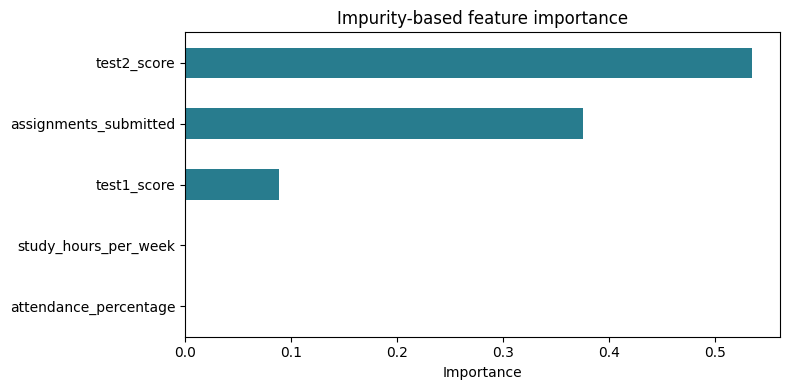

In [11]:
importance = pd.Series(
    tree.feature_importances_, index=FEATURES, name="Importance"
).sort_values()
display(importance.sort_values(ascending=False).to_frame().round(4))
fig, ax = plt.subplots(figsize=(8, 4))
importance.plot.barh(ax=ax, color="#287c8e")
ax.set(title="Impurity-based feature importance", xlabel="Importance")
plt.tight_layout()
plt.show()

## 13. Overfitting demonstration
Fit an unrestricted tree on the same training data. Compare its training score and complexity with the restricted tree. An unrestricted tree can memorize noise.

A high training score is not evidence of better generalization. We do not use the test set to choose a depth here. For tuning, use cross-validation within training data, respecting student groups if present, and reserve the test set for the final evaluation.

In [12]:
unrestricted = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("tree", DecisionTreeClassifier(random_state=RANDOM_STATE))
])
unrestricted.fit(X_train, y_train)
complexity = []
for name, estimator in [("Depth-limited", model), ("Unrestricted", unrestricted)]:
    fitted_tree = estimator.named_steps["tree"]
    complexity.append({
        "Model": name,
        "Training accuracy": estimator.score(X_train, y_train),
        "Depth": fitted_tree.get_depth(),
        "Leaves": fitted_tree.get_n_leaves()
    })
display(pd.DataFrame(complexity).round(4))
print("Depth-limited test accuracy:", round(model.score(X_test, y_test), 4))

,Model,Training accuracy,Depth,Leaves
0,Depth-limited,0.9738,3,7
1,Unrestricted,1.0000,8,27


Depth-limited test accuracy: 0.96


## 14. Classify one new record and trace its path
The example below is hypothetical. Use the original dataset's units. Prediction is an educational estimate, not an automatic academic decision.

In [13]:
if DATASET == "student":
    new_record = pd.DataFrame([{
        "test1_score": 65, "test2_score": 70,
        "attendance_percentage": 85, "study_hours_per_week": 12,
        "assignments_submitted": 90
    }])
else:
    new_record = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=FEATURES)

predicted_class = model.predict(new_record)[0]
print("Predicted class:", class_map[predicted_class])
display(pd.DataFrame(
    model.predict_proba(new_record),
    columns=[f"P({class_map[label]})" for label in model.classes_]
).round(3))

# Trace the exact transformed values used by the classifier.
values = model.named_steps["imputer"].transform(new_record)
visited_nodes = tree.decision_path(values).indices
for node in visited_nodes:
    feature_id = tree.tree_.feature[node]
    if feature_id >= 0:
        value = values[0, feature_id]
        threshold = tree.tree_.threshold[node]
        branch = "left" if value <= threshold else "right"
        print(f"{FEATURES[feature_id]} = {value:.2f}; threshold {threshold:.2f} -> {branch}")
    else:
        print(f"Reached leaf {node}.")

Predicted class: Pass


,P(Fail),P(Pass)
0,0.0,1.0


test2_score = 70.00; threshold 51.55 -> right
assignments_submitted = 90.00; threshold 49.95 -> right
test1_score = 65.00; threshold 48.00 -> right
Reached leaf 12.


## 15. Lab observations
After running all cells on the selected dataset, record:
1. Input variables, target classes and split sizes.
2. Trained tree depth and number of leaves.
3. Accuracy, macro F1 and majority-baseline accuracy.
4. Two frequent errors from the confusion matrix.
5. The root split and one complete root-to-leaf rule.
6. The difference in complexity between restricted and unrestricted trees.

**Conclusion template:** “A decision tree classifier was built for ___. The depth-limited model had ___ leaves and obtained test accuracy ___ and macro F1 ___. Compared with the majority baseline, ___. Its main limitation was ___.”

## Viva questions with answers
1. **What is a decision tree?** A model that makes predictions through successive feature-based tests.
2. **What does Gini impurity measure?** Class mixing in a node; zero means a pure node.
3. **What is a leaf?** A terminal node that supplies a class prediction.
4. **What is overfitting?** Learning training-specific noise or patterns that do not generalize.
5. **Why limit depth?** To reduce complexity and the risk of overfitting.
6. **Does a tree require feature scaling?** Generally no; splits compare feature values against thresholds.
7. **What is pre-pruning?** Restricting growth using settings such as maximum depth or minimum leaf size.
8. **What is post-pruning?** Removing branches after growth, for example with cost-complexity pruning.
9. **Does feature importance imply causation?** No.
10. **Can trees handle multiclass problems?** Yes, as demonstrated by Iris mode.
11. **Why keep final grades out of student inputs?** They may reveal the target and be unavailable at prediction time.
12. **Why can a probability of 1 be wrong?** A pure training leaf may still generalize poorly.

## Practice
- Run the alternative dataset mode.
- Try `criterion="entropy"` using validation data.
- Tune `max_depth` and `min_samples_leaf` with training-only cross-validation.
- Explore cost-complexity pruning using `ccp_alpha`.
- Compare against Experiment 4 only when dataset rows, split, target and metrics match.